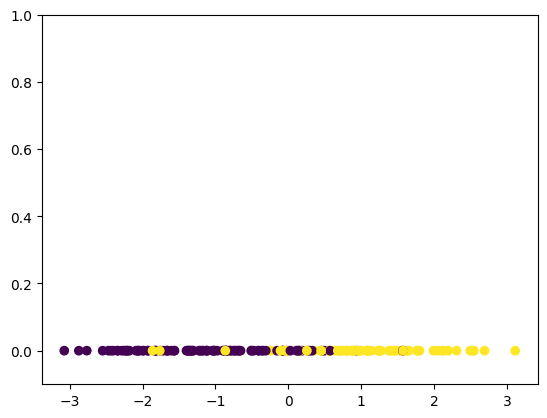

In [221]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

imbalance_factor = 0.75
n0 = 100
n1 = int(n0 * imbalance_factor)

X, y = make_blobs(n_samples=[n0, n1], centers=[[-1], [1]])

plt.scatter(X, np.zeros(X.shape[0]), c=y)
plt.ylim(-0.1, 1)
plt.show()

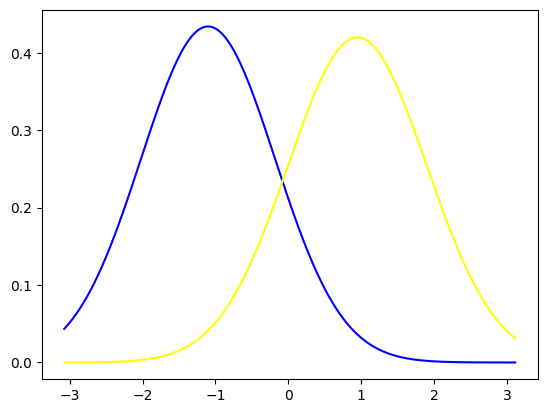

In [222]:
from scipy.stats import norm

x = np.linspace(np.min(X), np.max(X), 1000)

loc0, scale0 = np.mean(X[y == 0]), np.std(X[y == 0])
loc1, scale1 = np.mean(X[y == 1]), np.std(X[y == 1])

pdf0 = norm.pdf(x, loc=loc0, scale=scale0)
pdf1 = norm.pdf(x, loc=loc1, scale=scale1)

plt.plot(x, pdf0, c='blue')
plt.plot(x, pdf1, c='yellow')
plt.show()

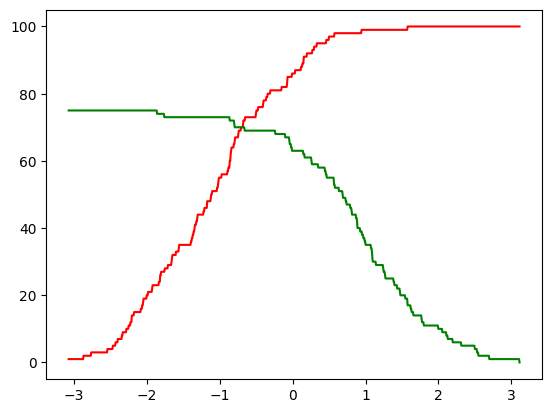

In [223]:
from sklearn.metrics import confusion_matrix

def pred(X, threshold):
  return np.where(X > threshold, 1, 0)

TN = []
TP = []

for threshold in x:
  y_pred = pred(X, threshold)
  tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
  TN.append(tn)
  TP.append(tp)

plt.plot(x, TN, c='red')
plt.plot(x, TP, c='green')
plt.show()

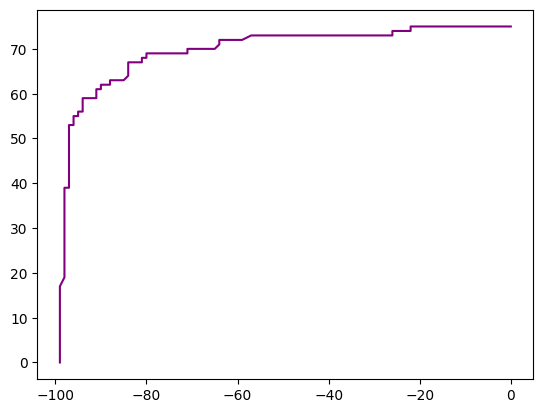

In [224]:
plt.plot(1 - np.array(TN), TP, c='purple')
plt.show()